# Import Library

In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 831.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [4]:
import math
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import time
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    label_ranking_average_precision_score,
    label_ranking_loss,
    coverage_error)
from sklearn.utils import shuffle
from scipy.signal import resample
from sklearn.preprocessing import OneHotEncoder
from keras.models import Model
from keras.layers import (
    Input,
    Dense,
    Conv1D,
    MaxPooling1D,
    Softmax,
    Add,
    Flatten,
    Activation)
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# Exploratory Data Analysis - EDA

## Membaca Data

In [5]:
# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
df2 = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
df = pd.concat([df1, df2])

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [6]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi Sinyal

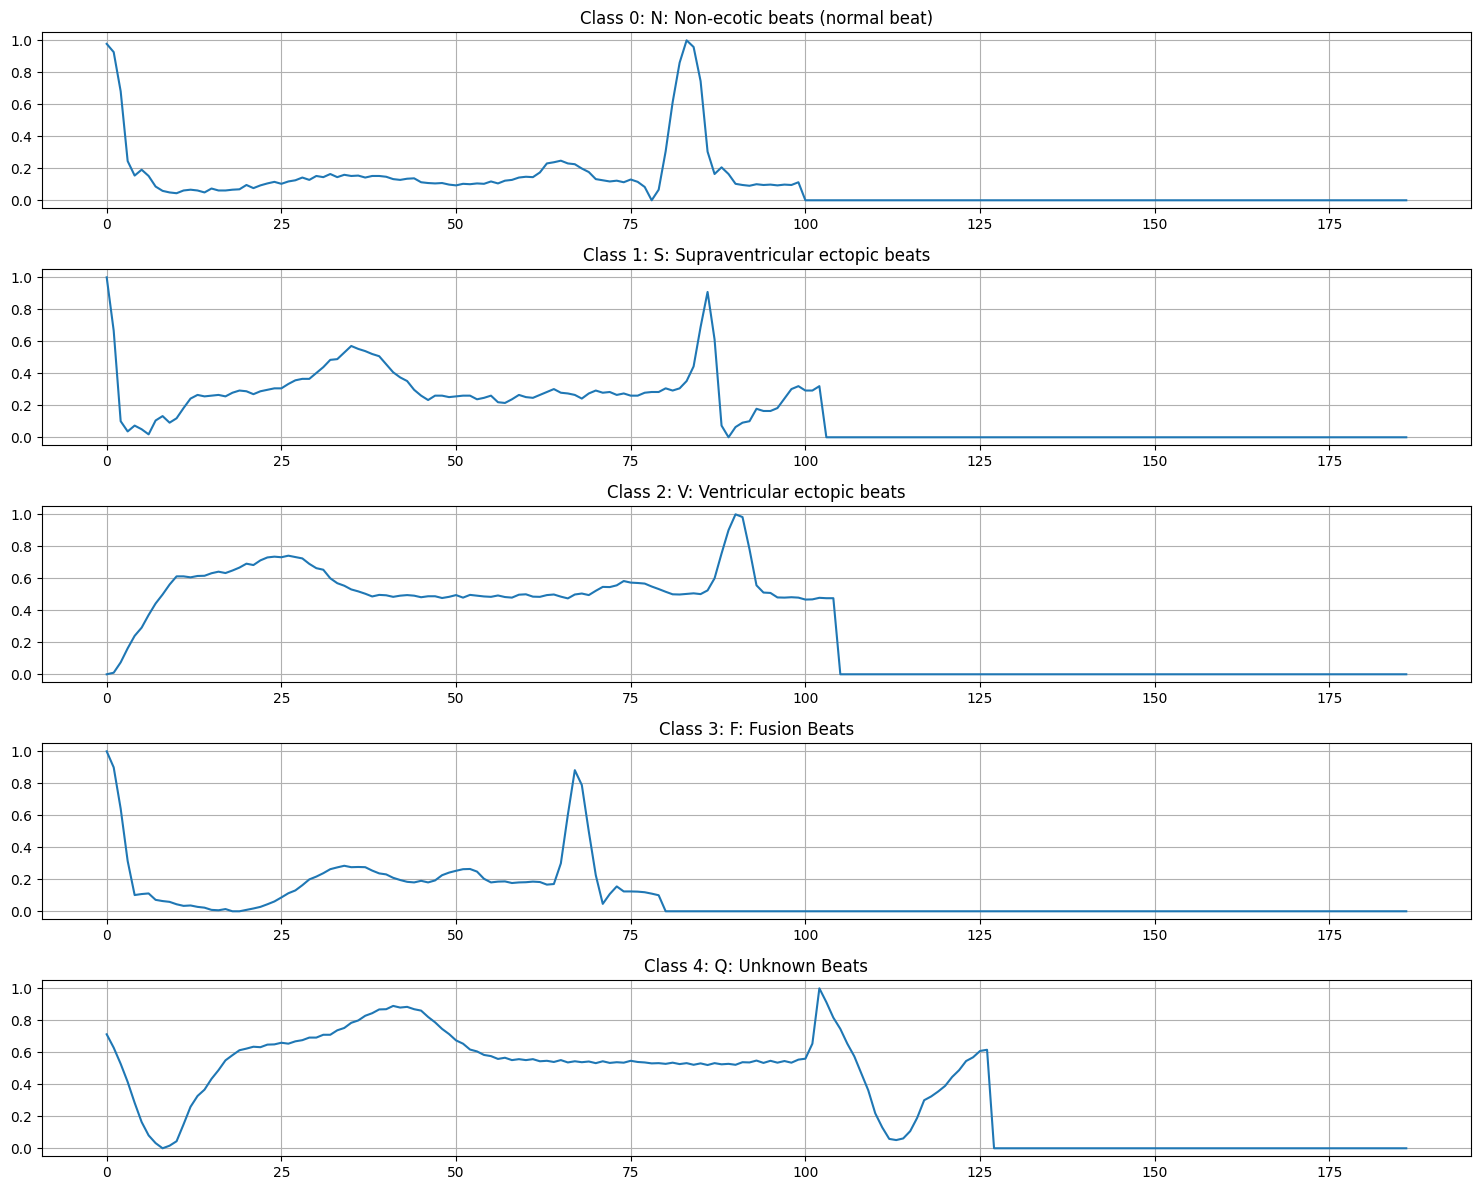

In [7]:
classes = [0, 1, 2, 3, 4]
labels = [
    'N: Non-ecotic beats (normal beat)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(15, 12))

for i, cls in enumerate(classes):
    # Ambil sampel pertama untuk setiap kelas
    sample = df[df[187] == cls].iloc[0, :187]

    plt.subplot(5, 1, i + 1)
    plt.plot(sample)
    plt.title(f"Class {cls}: {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Analisis Distribusi Kelas

Jumlah sampel per kelas:
187
0.0    90589
1.0     2779
2.0     7236
3.0      803
4.0     8039
Name: count, dtype: int64


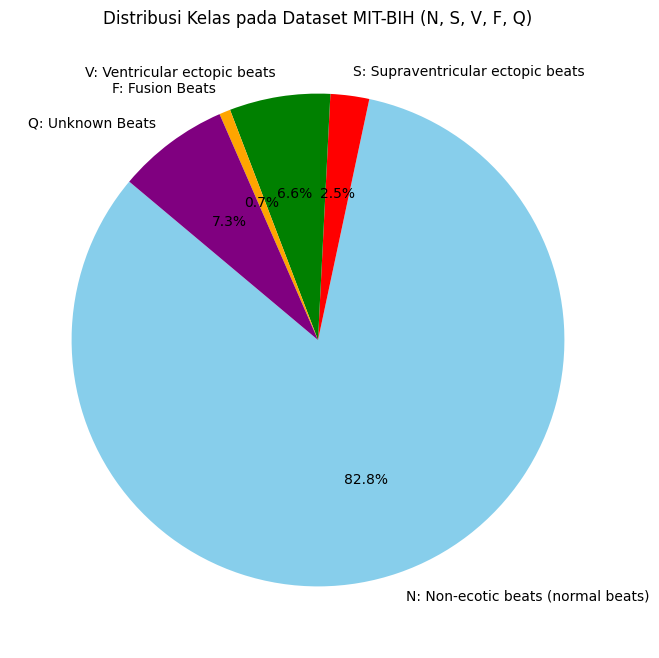

In [8]:
count_classes = df[187].value_counts().sort_index()
print("Jumlah sampel per kelas:")
print(count_classes)

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(10, 8))
plt.pie(count_classes, labels=labels_detailed, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'red', 'green', 'orange', 'purple'])
plt.title("Distribusi Kelas pada Dataset MIT-BIH (N, S, V, F, Q)")
plt.show()

# Data Preprocessing

## Pemisahan Fitur dan Target

In [9]:
X = df.iloc[:, :187].values
y = df.iloc[:, 187].values

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (109446, 187)
Ukuran Target (y): (109446,)


## Penanganan Data Tidak Seimbang

In [10]:
def resample_dataset(df):
    # Pisahkan setiap kelas
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Target jumlah sampel per kelas
    target_samples = 20000

    # Resampling untuk setiap kelas
    df_0_resampled = df_0.sample(n=target_samples, random_state=42) # Undersampling
    df_1_resampled = df_1.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_2_resampled = df_2.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_3_resampled = df_3.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_4_resampled = df_4.sample(n=target_samples, replace=True, random_state=42) # Oversampling

    # Gabungkan kembali
    df_resampled = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled, df_3_resampled, df_4_resampled])
    return df_resampled

# Terapkan resampling
df_balanced = resample_dataset(df)

# Update X dan y dengan data yang sudah seimbang
X_balanced = df_balanced.iloc[:, :187].values
y_balanced = df_balanced.iloc[:, 187].values

print("Distribusi kelas setelah resampling:")
print(df_balanced[187].value_counts().sort_index())
print("\nUkuran X_balanced:", X_balanced.shape)

Distribusi kelas setelah resampling:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64

Ukuran X_balanced: (100000, 187)


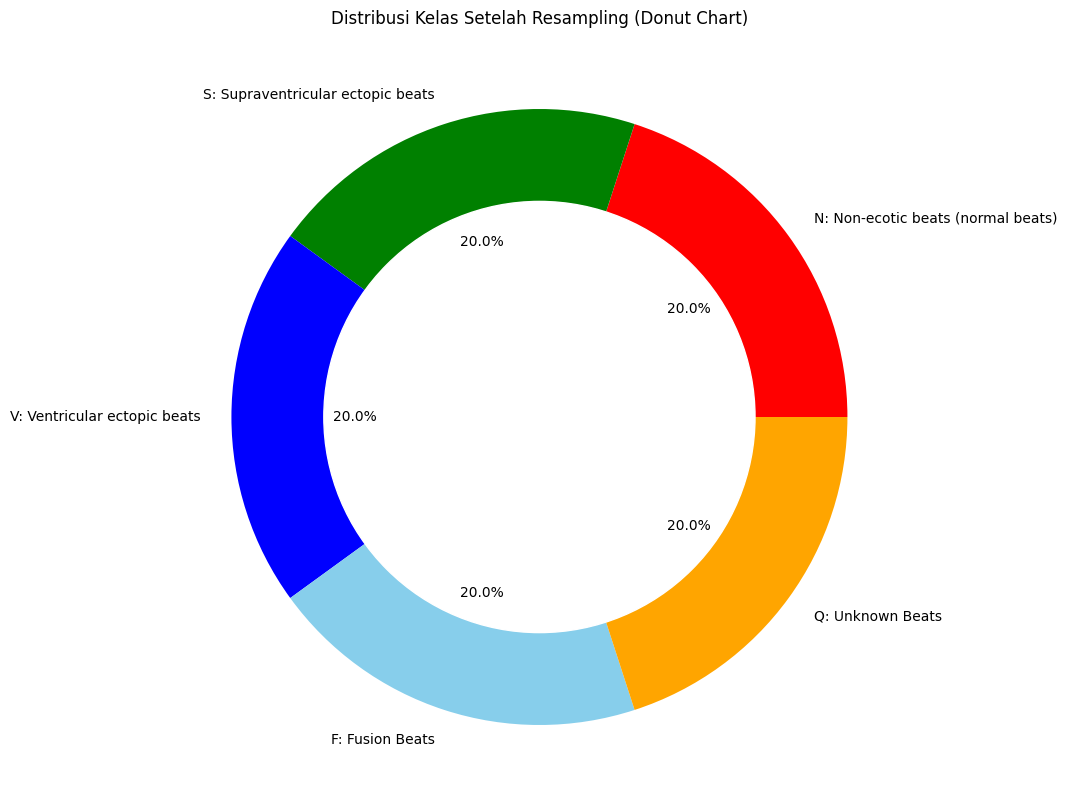

In [11]:
equilibre = df_balanced[187].value_counts()

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(20,10))
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(equilibre, labels=labels_detailed, colors=['red','green','blue','skyblue','orange'], autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Distribusi Kelas Setelah Resampling (Donut Chart)")
plt.show()

## Reshaping Data

In [12]:
# Reshaping data fitur dari 2D (100000, 187) menjadi 3D (100000, 187, 1)
X_3d = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)

print("Ukuran X_balanced awal:", X_balanced.shape)
print("Ukuran X setelah Reshape (X_3d):", X_3d.shape)

Ukuran X_balanced awal: (100000, 187)
Ukuran X setelah Reshape (X_3d): (100000, 187, 1)


# Pembangunan Model (Modeling)

In [13]:
# 1. One-hot Encoding untuk Target
# y_balanced saat ini berbentuk (100000,)
ohe = OneHotEncoder()
y_balanced_ohe = ohe.fit_transform(y_balanced.reshape(-1, 1)).toarray()

# 2. Definisi Arsitektur Model 1D-CNN
def build_model(input_shape):
    inp = Input(shape=input_shape)

    # Convolutional Block 1
    x = Conv1D(64, kernel_size=5, activation='relu', padding="same")(inp)

    # Residual Block 1
    shortcut = x
    x = Conv1D(64, kernel_size=5, activation='relu', padding="same")(x)
    x = Conv1D(64, kernel_size=5, activation='linear', padding="same")(x)
    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=5, strides=2)(x)

    # Residual Block 2
    shortcut = x
    x = Conv1D(64, kernel_size=5, activation='relu', padding="same")(x)
    x = Conv1D(64, kernel_size=5, activation='linear', padding="same")(x)
    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=5, strides=2)(x)

    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(5, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)

    return model

# Inisialisasi Model
model = build_model(input_shape=(187, 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 64)   │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 187, 64)   │     20,544 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 187, 64)   │     20,544 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 187, 64)   │          0 │ conv1d[0][0],     │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 187, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 92, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 92, 64)    │     20,544 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 92, 64)    │     20,544 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 92, 64)    │          0 │ max_pooling1d[0]… │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 92, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 44, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2816)      │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     90,144 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        165 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 173,925 (679.39 KB)

 Trainable params: 173,925 (679.39 KB)

 Non-trainable params: 0 (0.00 B)

## Split Data

In [14]:
# Tahap 1: Split 70% Training dan 30% Sisa (Val + Test)
X_train, X_rem, y_train, y_rem = train_test_split(
    X_3d, y_balanced_ohe, test_size=0.3, random_state=42, stratify=y_balanced_ohe
)

# Tahap 2: Split Sisa (30%) menjadi 50% Val dan 50% Test (sehingga masing-masing 15% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_val shape:   {X_val.shape} (15%)")
print(f"X_test shape:  {X_test.shape} (15%)")

X_train shape: (70000, 187, 1) (70%)
X_val shape:   (15000, 187, 1) (15%)
X_test shape:  (15000, 187, 1) (15%)


# Training Model (1)

In [ ]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate1 = 0.01
epochs = 20
batch_size = 32

model.compile(
    optimizer=Adam(learning_rate=learning_rate1),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8887 - loss: 0.3388
Epoch 1: val_accuracy improved from None to 0.93693, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.8993 - loss: 0.3026 - val_accuracy: 0.9369 - val_loss: 0.2011
Epoch 2/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9205 - loss: 0.2427
Epoch 2: val_accuracy did not improve from 0.93693
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9204 - loss: 0.2457 - val_accuracy: 0.9313 - val_loss: 0.2185
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9332 - loss: 0.2116
Epoch 3: val_accuracy did not improve from 0.93693
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 56s 26ms/step - accuracy: 0.9361 - loss: 0.2021 - val_accuracy: 0.9231 - val_loss: 0.2404
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9396 - loss: 0.1983
Epoch 4: val_accuracy improved from 0.936

# Evaluasi Metrik (1)

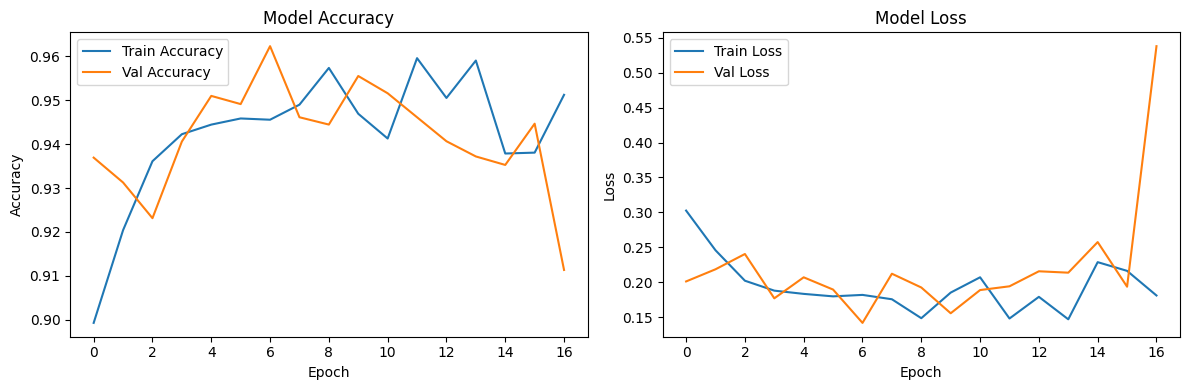

In [ ]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time1 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss1, accuracy1 = model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate1}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss1:.4f}")
print(f"Test Accuracy: {accuracy1:.4f}")
print(f"Total Prediction Time: {total_time1:.4f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Test Loss: 0.1379
Test Accuracy: 0.9631
Total Prediction Time: 3.1951 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.941     0.927     0.934      3000
Supraventricular      0.941     0.960     0.951      3000
     Ventricular      0.973     0.960     0.966      3000
          Fusion      0.973     0.974     0.974      3000
         Unknown      0.987     0.994     0.991      3000

        accuracy                          0.963     15000
       macro avg      0.963     0.963     0.963     15000
    weighted avg      0.963     0.963     0.963     15000



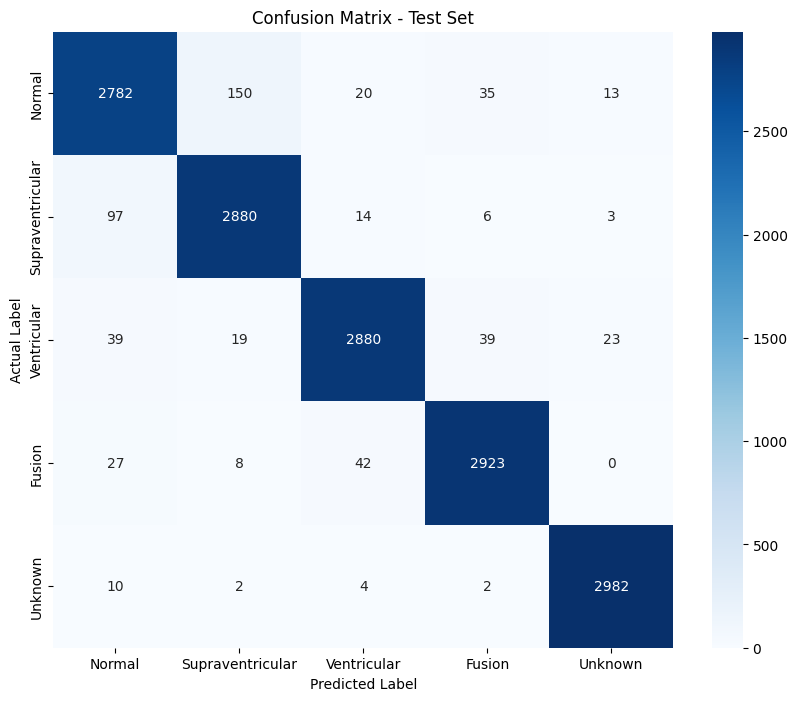

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (2)

In [13]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate2 = 0.005
epochs = 20
batch_size = 32

model.compile(
    optimizer=Adam(learning_rate=learning_rate2),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9278 - loss: 0.2068
Epoch 1: val_accuracy improved from None to 0.94927, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 195s 87ms/step - accuracy: 0.9336 - loss: 0.1911 - val_accuracy: 0.9493 - val_loss: 0.1465
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9505 - loss: 0.1432
Epoch 2: val_accuracy improved from 0.94927 to 0.95240, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 186s 85ms/step - accuracy: 0.9514 - loss: 0.1409 - val_accuracy: 0.9524 - val_loss: 0.1427
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9595 - loss: 0.1194
Epoch 3: val_accuracy improved from 0.95240 to 0.96773, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 186s 85ms/step - accuracy: 0.9588 - lo

# Evaluasi Metrik (2)

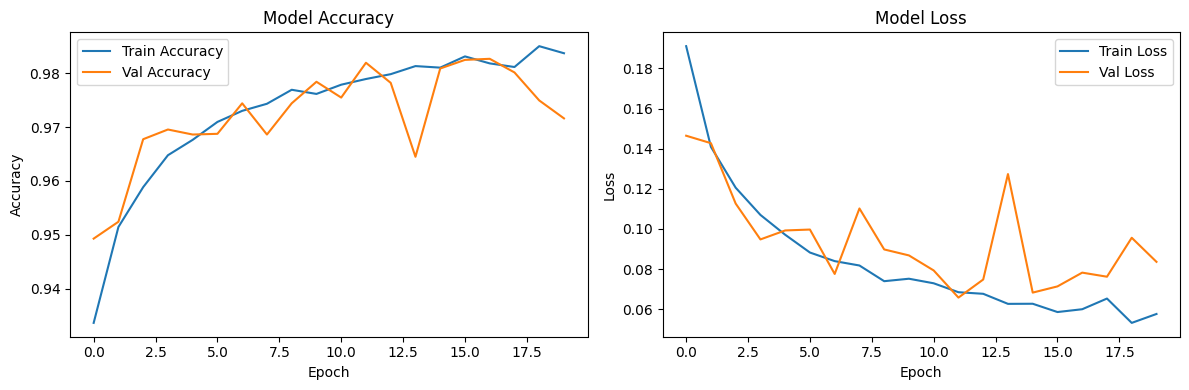

In [15]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time2 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss2, accuracy2 = model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate2}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")
print(f"Total Prediction Time: {total_time2:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step
Learning Rate: 0.005
Epochs: 20
Batch size: 32
Test Loss: 0.0611
Test Accuracy: 0.9841
Total Prediction Time: 11.31 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.966     0.977     0.971      3000
Supraventricular      0.986     0.983     0.985      3000
     Ventricular      0.991     0.977     0.984      3000
          Fusion      0.981     0.991     0.986      3000
         Unknown      0.997     0.993     0.995      3000

        accuracy                          0.984     15000
       macro avg      0.984     0.984     0.984     15000
    weighted avg      0.984     0.984     0.984     15000



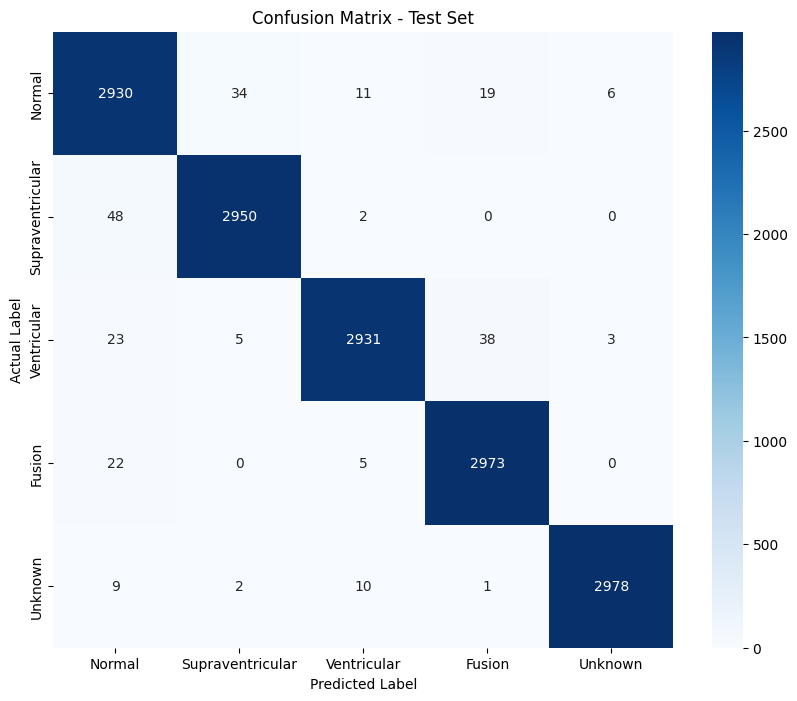

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

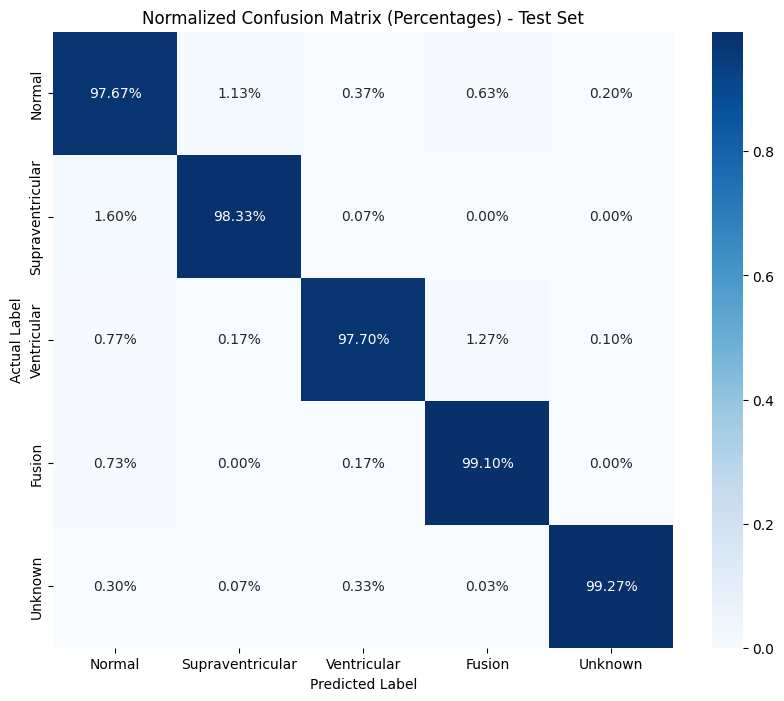

In [20]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (3)


In [ ]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate3 = 0.001
epochs = 20
batch_size = 32

model.compile(
    optimizer=Adam(learning_rate=learning_rate3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8837 - loss: 0.3243
Epoch 1: val_accuracy improved from None to 0.95233, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 63s 28ms/step - accuracy: 0.9137 - loss: 0.2401 - val_accuracy: 0.9523 - val_loss: 0.1335
Epoch 2/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9559 - loss: 0.1273
Epoch 2: val_accuracy did not improve from 0.95233
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9606 - loss: 0.1145 - val_accuracy: 0.9415 - val_loss: 0.1522
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9713 - loss: 0.0837
Epoch 3: val_accuracy improved from 0.95233 to 0.97660, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 61s 28ms/step - accuracy: 0.9730 - loss: 0.0800 - val_accuracy: 0.9766 - val_loss: 0.0716
Epoch 4/20
2184/2188 ━━━━━━━━━━━━━━━━━━━

# Evaluasi Metrik (3)


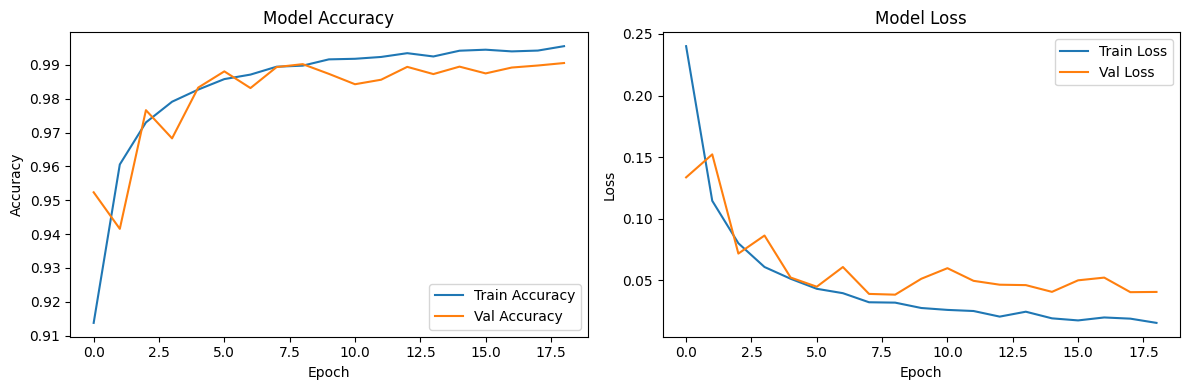

In [ ]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time3 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss3, accuracy3 = model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate3}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")
print(f"Total Prediction Time: {total_time3:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Test Loss: 0.0323
Test Accuracy: 0.9909
Total Prediction Time: 3.0841 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.991     0.976     0.983      3000
Supraventricular      0.986     0.994     0.990      3000
     Ventricular      0.995     0.987     0.991      3000
          Fusion      0.985     1.000     0.992      3000
         Unknown      0.998     0.997     0.997      3000

        accuracy                          0.991     15000
       macro avg      0.991     0.991     0.991     15000
    weighted avg      0.991     0.991     0.991     15000



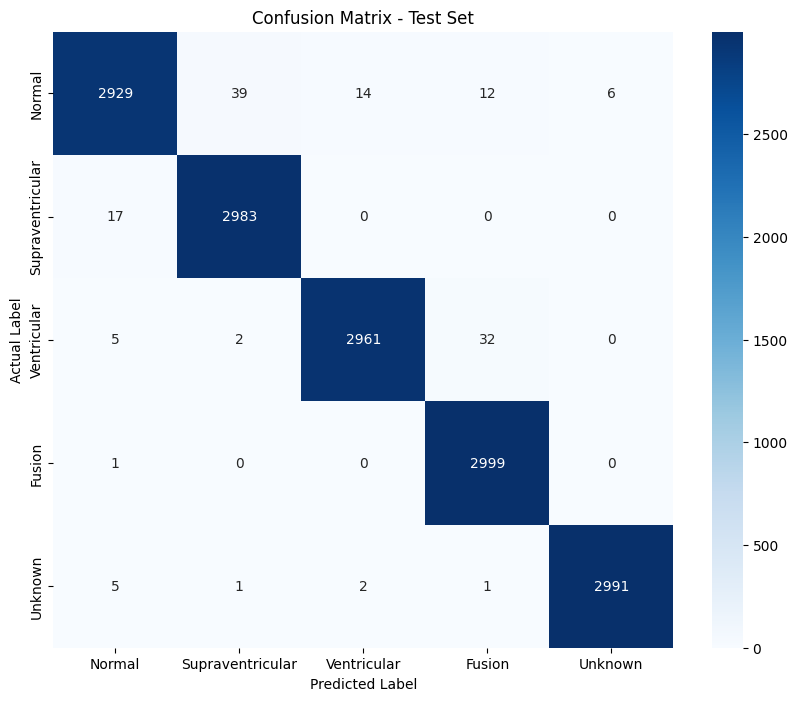

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (4)

In [15]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate4 = 0.0005
epochs = 20
batch_size = 32

model.compile(
    optimizer=Adam(learning_rate=learning_rate4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8007 - loss: 0.5319
Epoch 1: val_accuracy improved from None to 0.93380, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 64s 29ms/step - accuracy: 0.8776 - loss: 0.3363 - val_accuracy: 0.9338 - val_loss: 0.1971
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9444 - loss: 0.1604
Epoch 2: val_accuracy improved from 0.93380 to 0.94480, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - accuracy: 0.9497 - loss: 0.1455 - val_accuracy: 0.9448 - val_loss: 0.1495
Epoch 3/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9628 - loss: 0.1070
Epoch 3: val_accuracy improved from 0.94480 to 0.97387, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9658 - loss:

# Evaluasi Metrik (4)

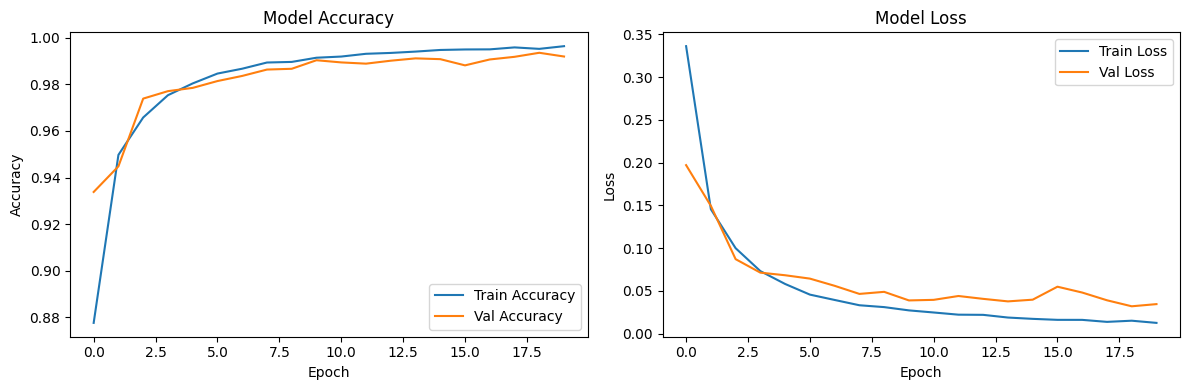

In [16]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time4 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss4, accuracy4 = model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate4}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss4:.4f}")
print(f"Test Accuracy: {accuracy4:.4f}")
print(f"Total Prediction Time: {total_time4:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Learning Rate: 0.0005
Epochs: 20
Batch size: 32
Test Loss: 0.0320
Test Accuracy: 0.9928
Total Prediction Time: 3.84 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.994     0.976     0.985      3000
Supraventricular      0.985     0.997     0.991      3000
     Ventricular      0.994     0.995     0.994      3000
          Fusion      0.992     0.998     0.995      3000
         Unknown      0.998     0.998     0.998      3000

        accuracy                          0.993     15000
       macro avg      0.993     0.993     0.993     15000
    weighted avg      0.993     0.993     0.993     15000



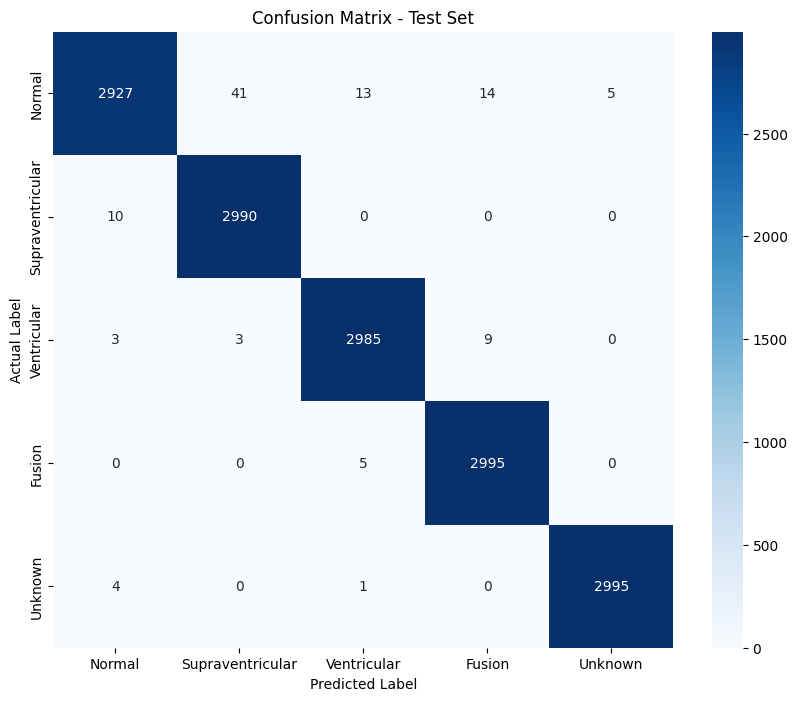

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

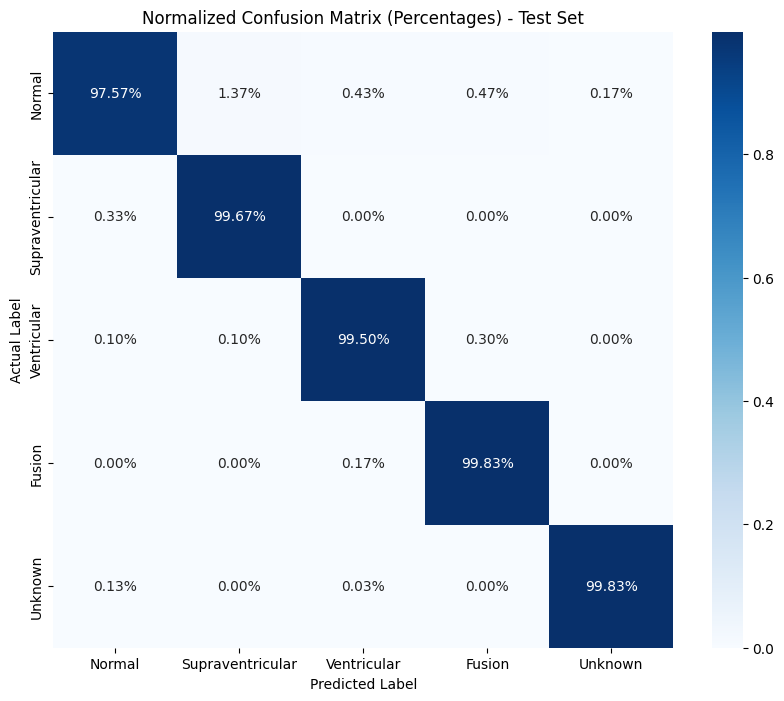

In [19]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [21]:
# Membuat data untuk tabel ringkasan
data = {
    'Learning Rate': [0.01, 0.005, 0.001, 0.0005],
    'Epochs': [20, 20, 20, 20],
    'Batch Size': [32, 32, 32, 32],
    'Test Accuracy': ['96.31%', '98.41%', '99.09%', '99.28%'],
    'Eval Runtime (Detik)': [3.20, 11.31, 3.08, 3.84]
}

# Membuat DataFrame
df_summary = pd.DataFrame(data)

# Menampilkan tabel
print("Summary Statistik Performa Model:")
display(df_summary)

Summary Statistik Performa Model:


,Learning Rate,Epochs,Batch Size,Test Accuracy,Eval Runtime (Detik)
0,0.0100,20,32,96.31%,3.20
1,0.0050,20,32,98.41%,11.31
2,0.0010,20,32,99.09%,3.08
3,0.0005,20,32,99.28%,3.84


# Penyimpanan dan Deployment

In [22]:
# 1. Simpan Model Utama
model.save('mitbih_cnn_model.keras')
print("Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'")

# 2. Simpan OneHotEncoder (Sangat penting untuk tahap inferensi nanti)
with open('encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("Encoder berhasil disimpan sebagai 'encoder.pkl'")

Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'
Encoder berhasil disimpan sebagai 'encoder.pkl'
